# 01 — Exploratory Data Analysis
**Dataset**: Telco Customer Churn  
**Goal**: Understand distributions, churn patterns, correlations, flag issues.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = '../reports/figures/'
TARGET = 'Churn Value'

## 2. Load Data

In [2]:
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## 3. Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing_df)

Columns with missing values:


,Missing Count,Missing %
Churn Reason,5174,73.46


In [6]:
# Fix Total Charges dtype
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print('Total Charges nulls after conversion:', df['Total Charges'].isnull().sum())
print('Total Charges dtype:', df['Total Charges'].dtype)

Total Charges nulls after conversion: 11
Total Charges dtype: float64


## 5. Churn Distribution

Churn Rate: 26.54%


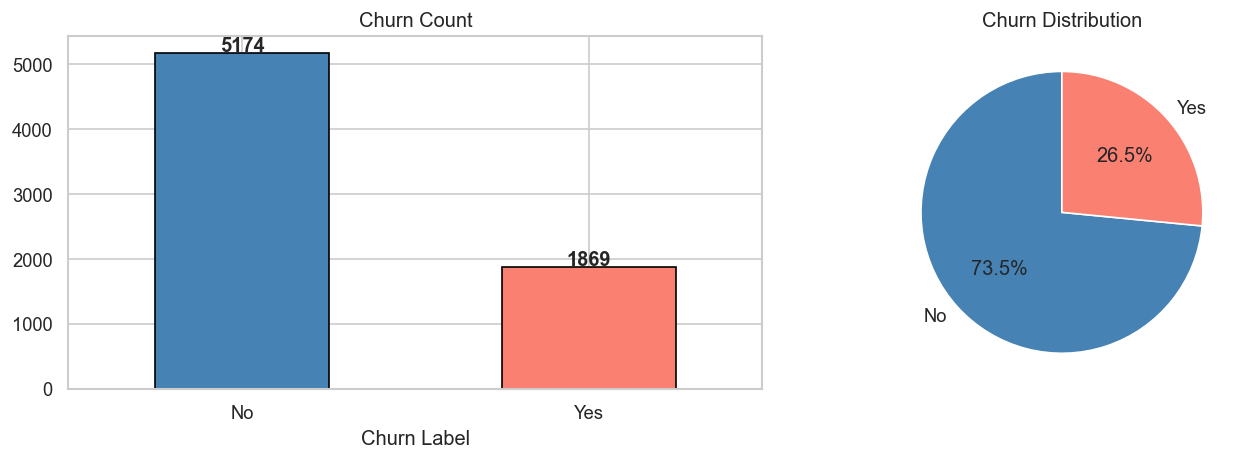

In [7]:
churn_counts = df['Churn Label'].value_counts()
churn_pct = df['Churn Label'].value_counts(normalize=True) * 100
print(f'Churn Rate: {churn_pct["Yes"]:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Churn Distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'churn_distribution.png')
plt.show()

## 6. Numerical Features Analysis

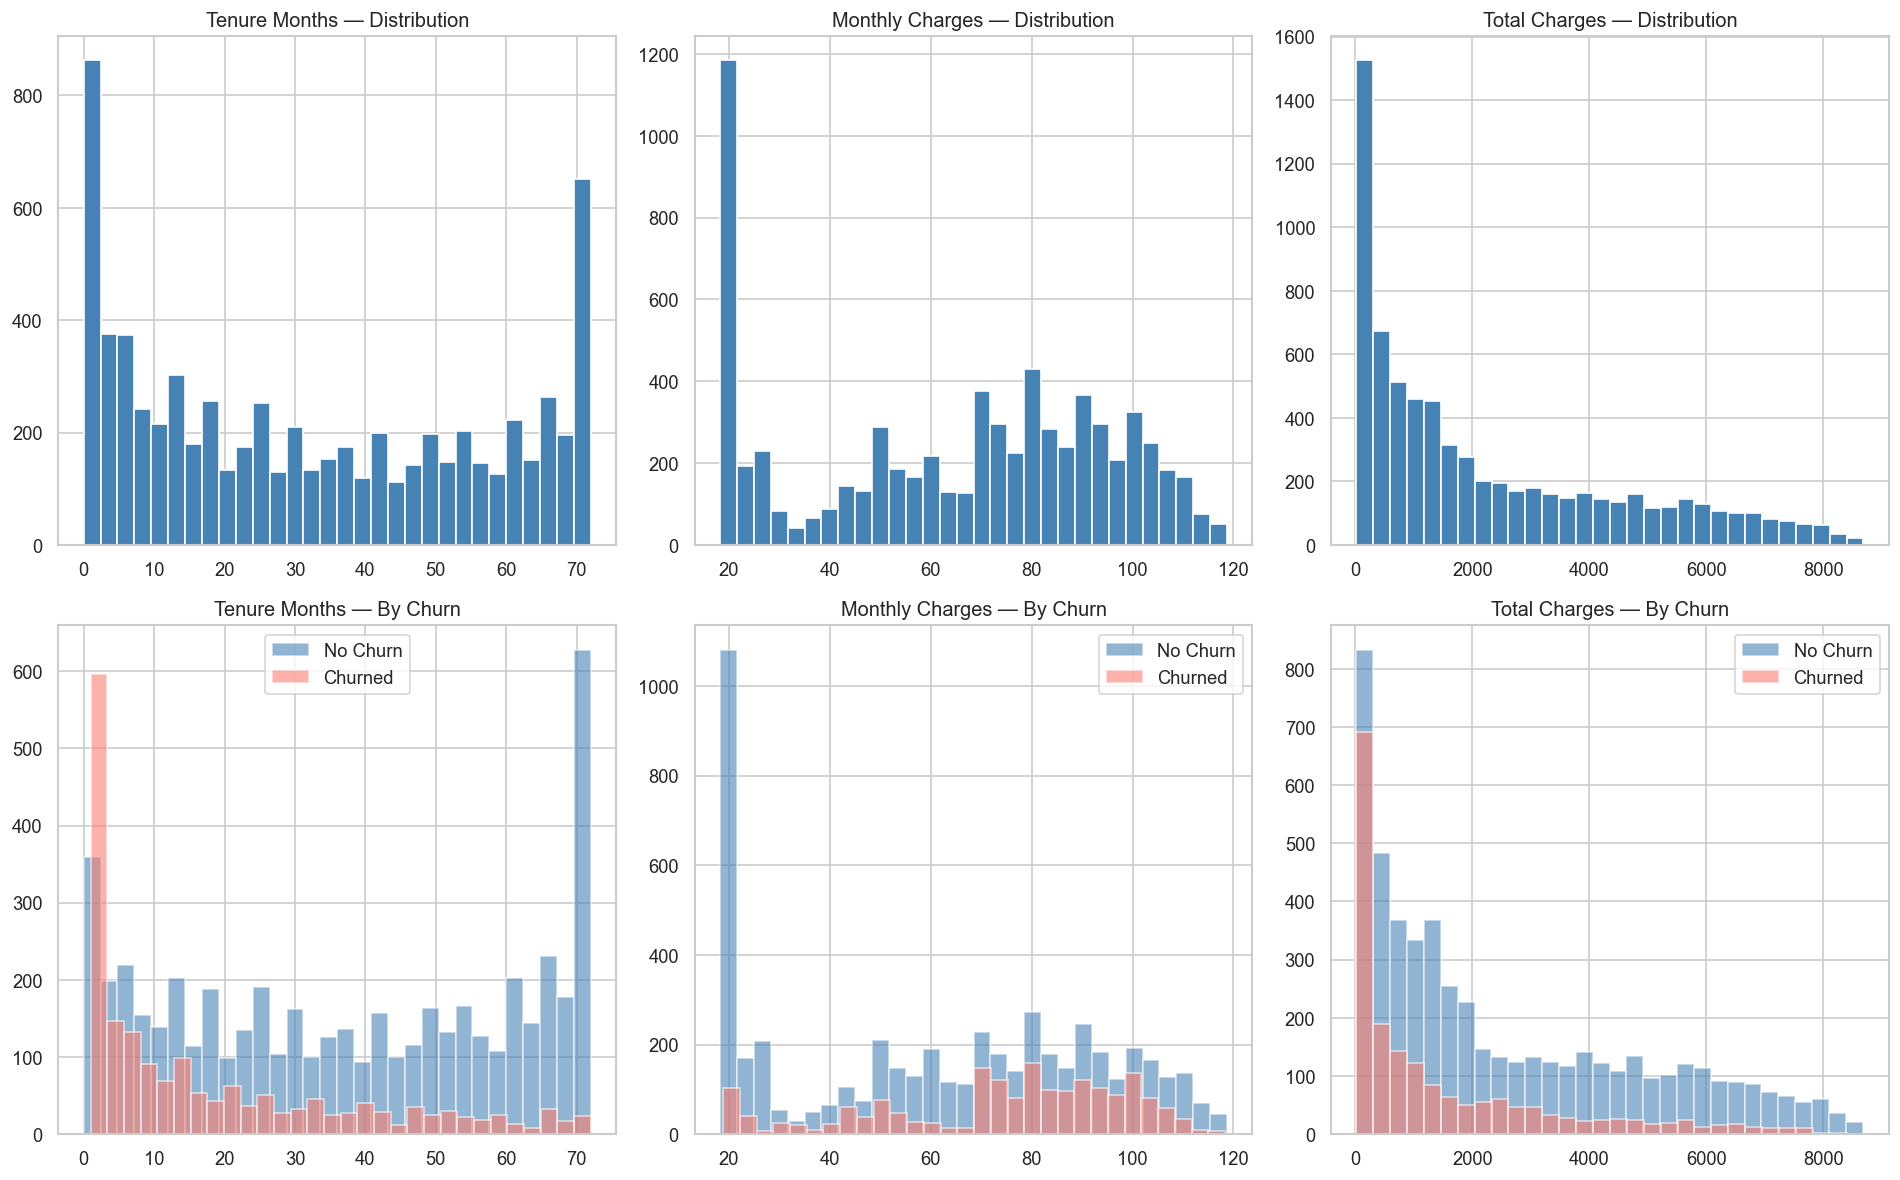

In [8]:
num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_features):
    df[col].hist(bins=30, ax=axes[0, i], color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution')
    df[df[TARGET]==0][col].hist(bins=30, ax=axes[1,i], alpha=0.6, label='No Churn', color='steelblue')
    df[df[TARGET]==1][col].hist(bins=30, ax=axes[1,i], alpha=0.6, label='Churned',  color='salmon')
    axes[1, i].set_title(f'{col} — By Churn')
    axes[1, i].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'numerical_distributions.png')
plt.show()

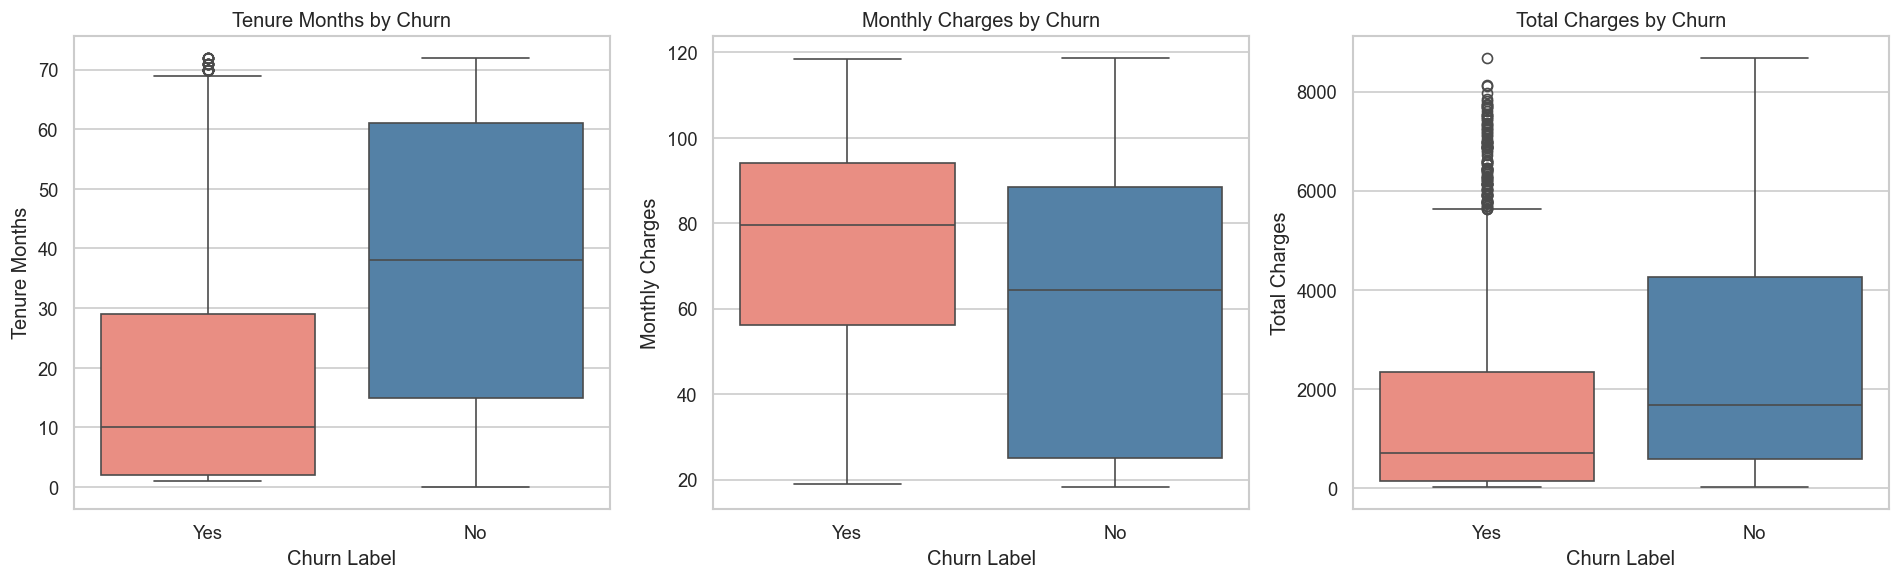

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churn Label', y=col, ax=axes[i],
                palette={'No': 'steelblue', 'Yes': 'salmon'})
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'numerical_boxplots.png')
plt.show()

## 7. Categorical Features Analysis

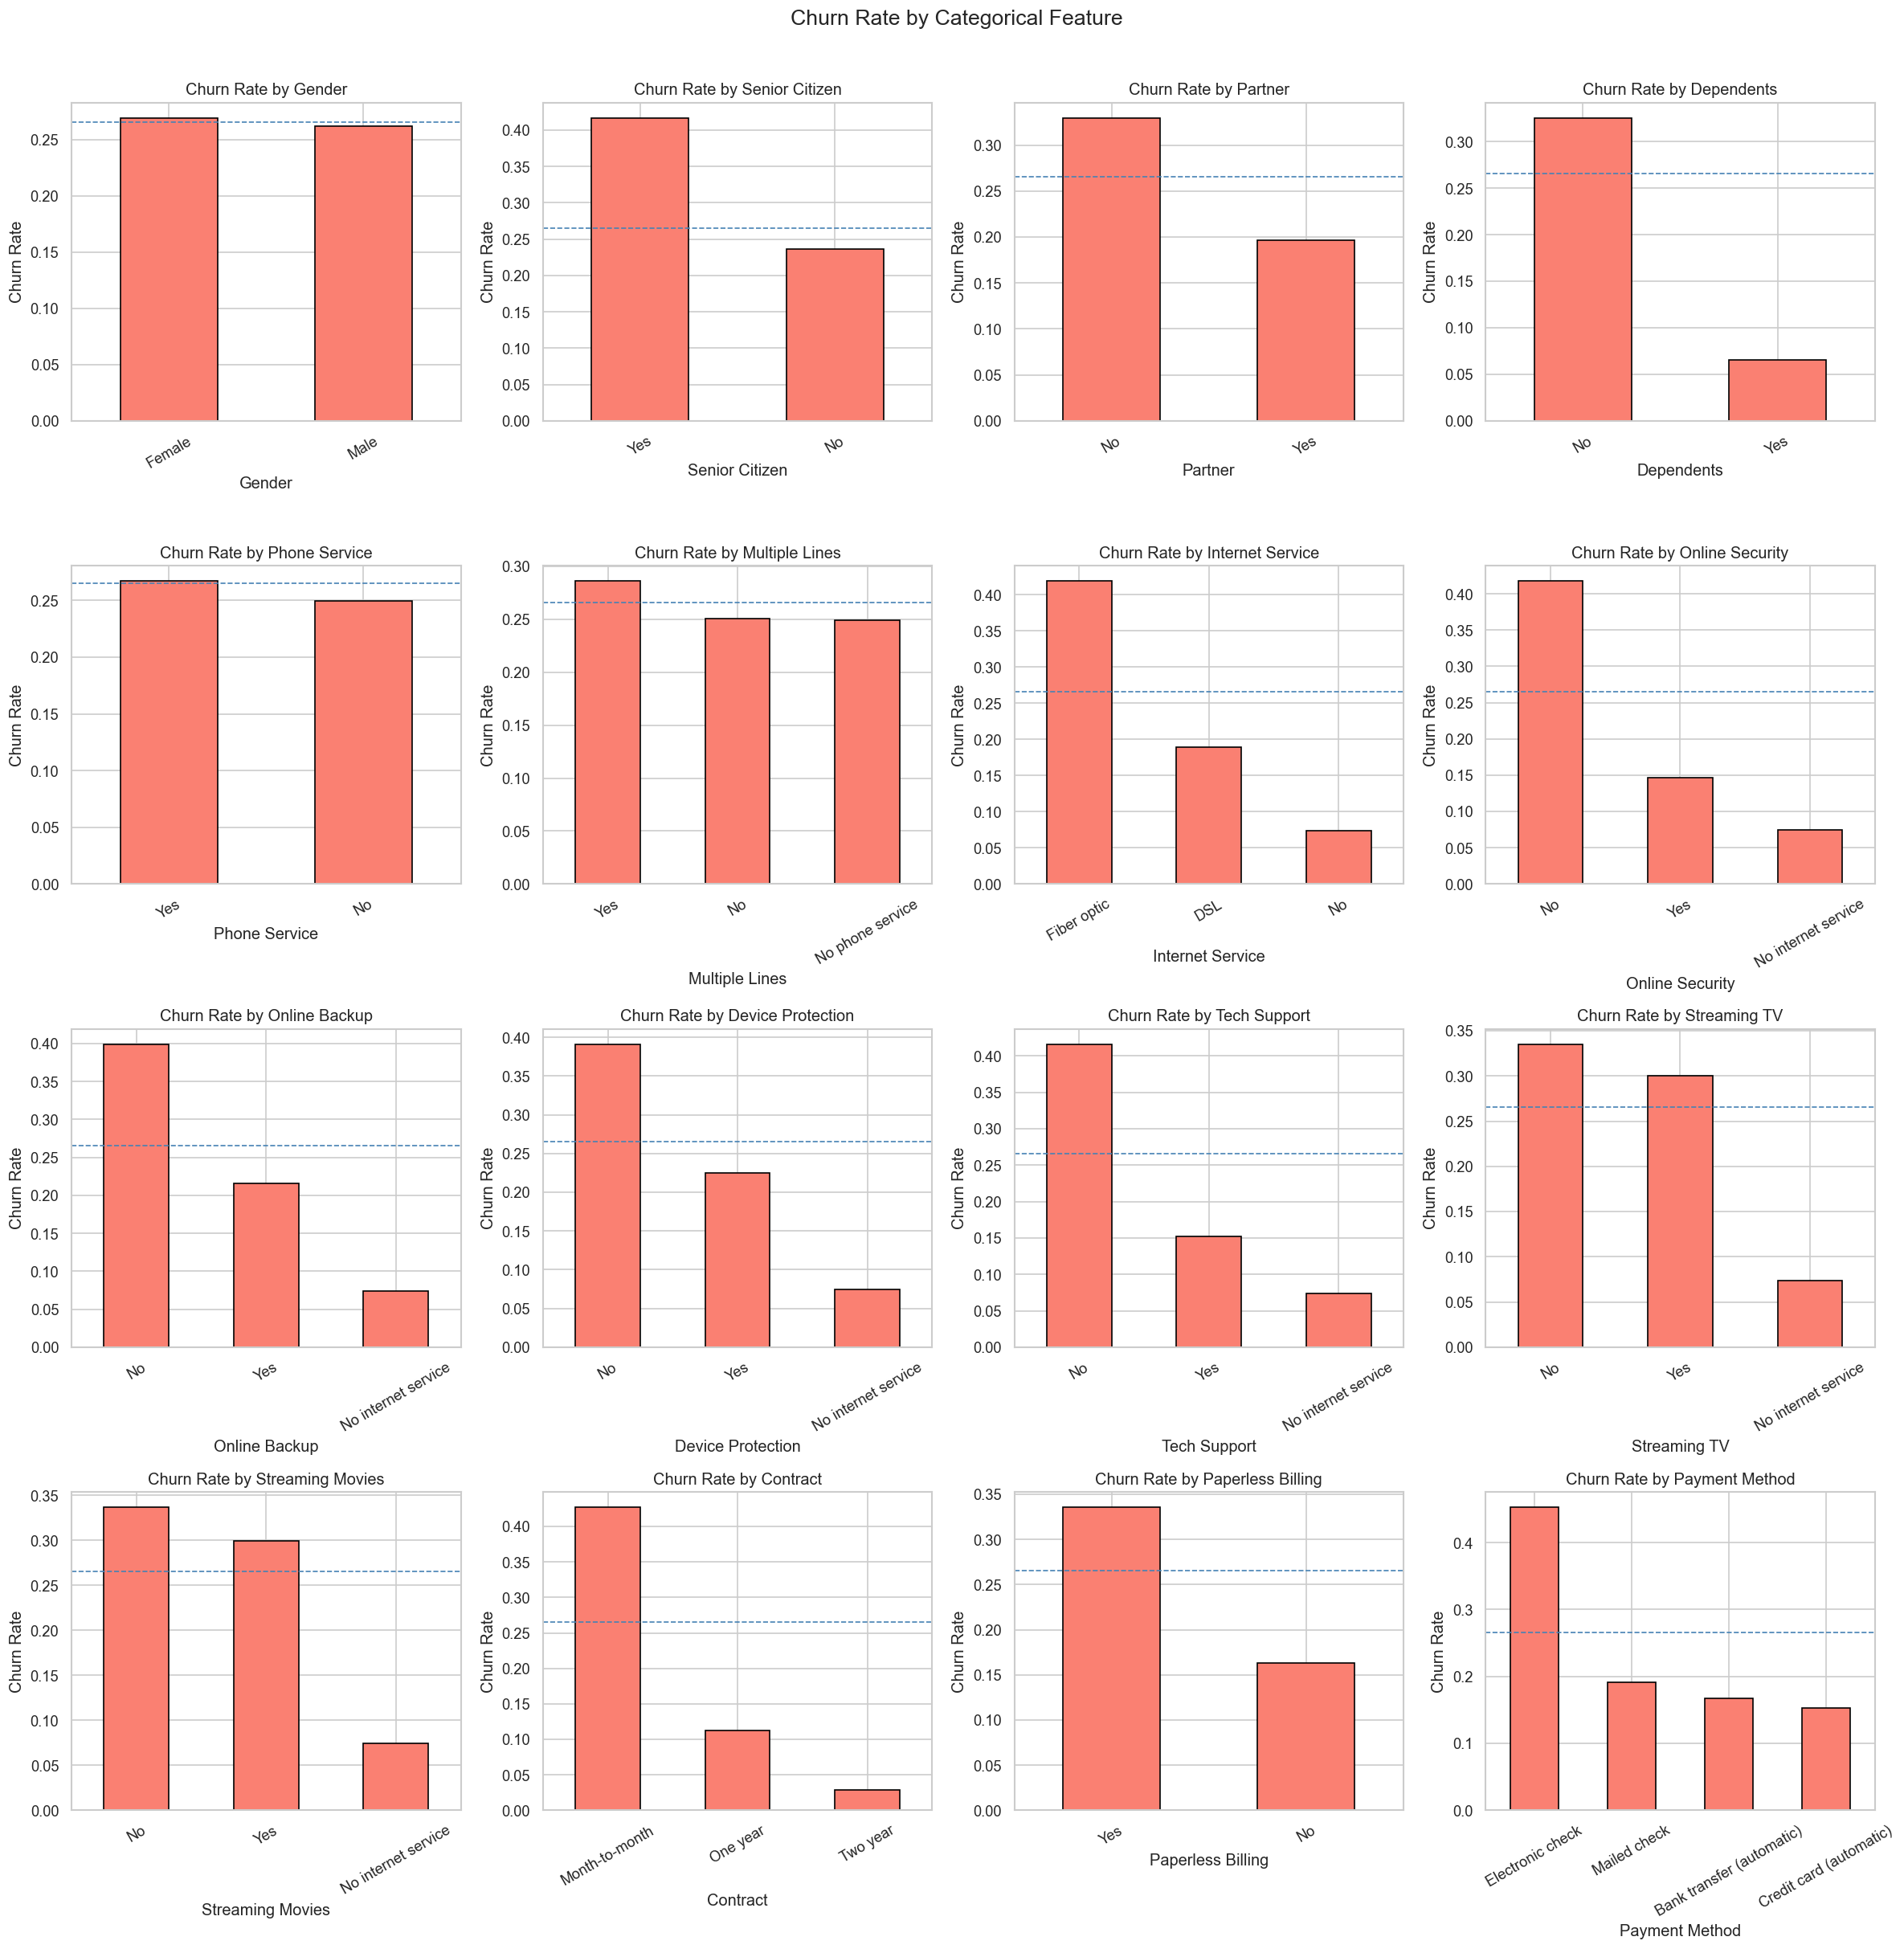

In [10]:
cat_features = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method'
]
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(df[TARGET].mean(), color='steelblue', linestyle='--', linewidth=1)
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Churn Rate by Categorical Feature', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'categorical_churn_rates.png', bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

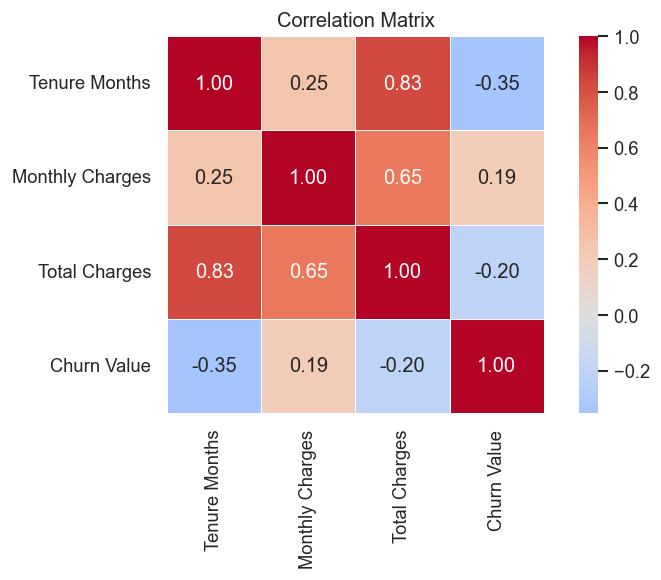

In [11]:
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'correlation_matrix.png')
plt.show()

## 9. Contract & Tenure Deep Dive

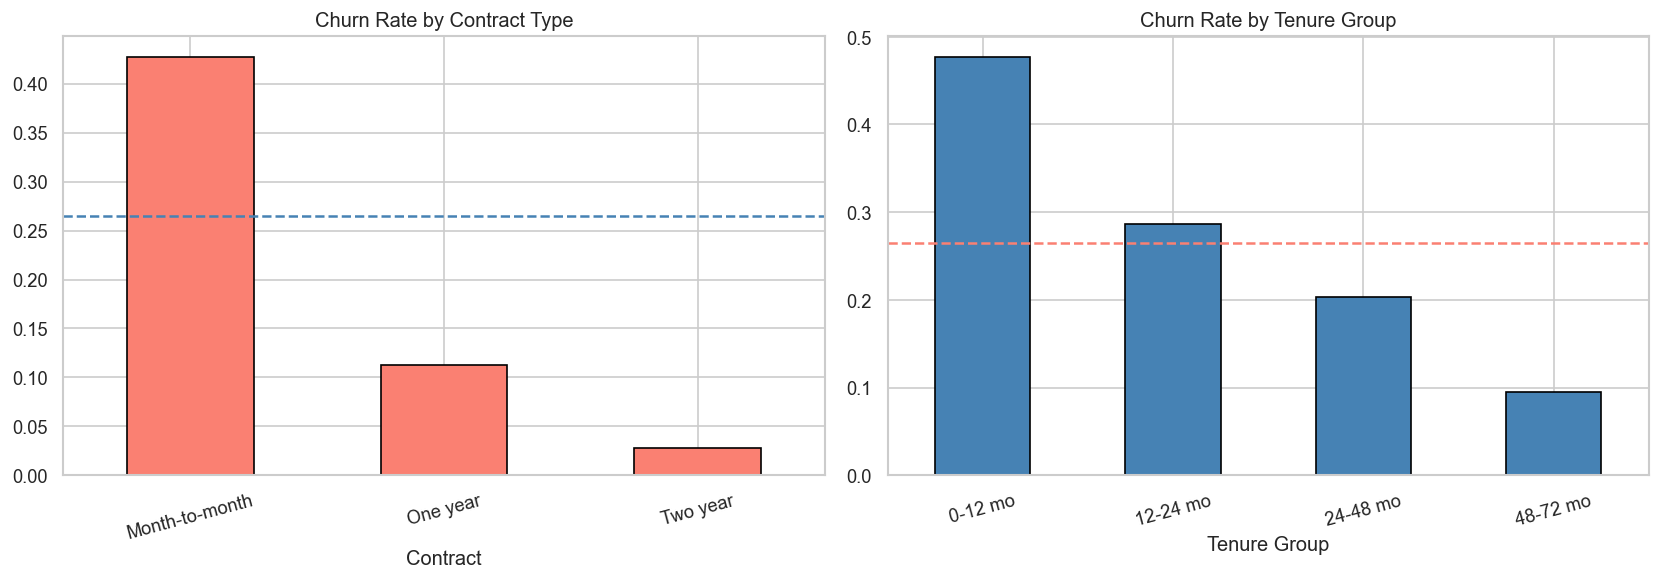

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
contract_churn = df.groupby('Contract')[TARGET].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(df[TARGET].mean(), color='steelblue', linestyle='--')

df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=[0,12,24,48,72],
                             labels=['0-12 mo','12-24 mo','24-48 mo','48-72 mo'])
tenure_churn = df.groupby('Tenure Group', observed=True)[TARGET].mean()
tenure_churn.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(df[TARGET].mean(), color='salmon', linestyle='--')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'contract_tenure_churn.png')
plt.show()

## 10. Top Churn Reasons

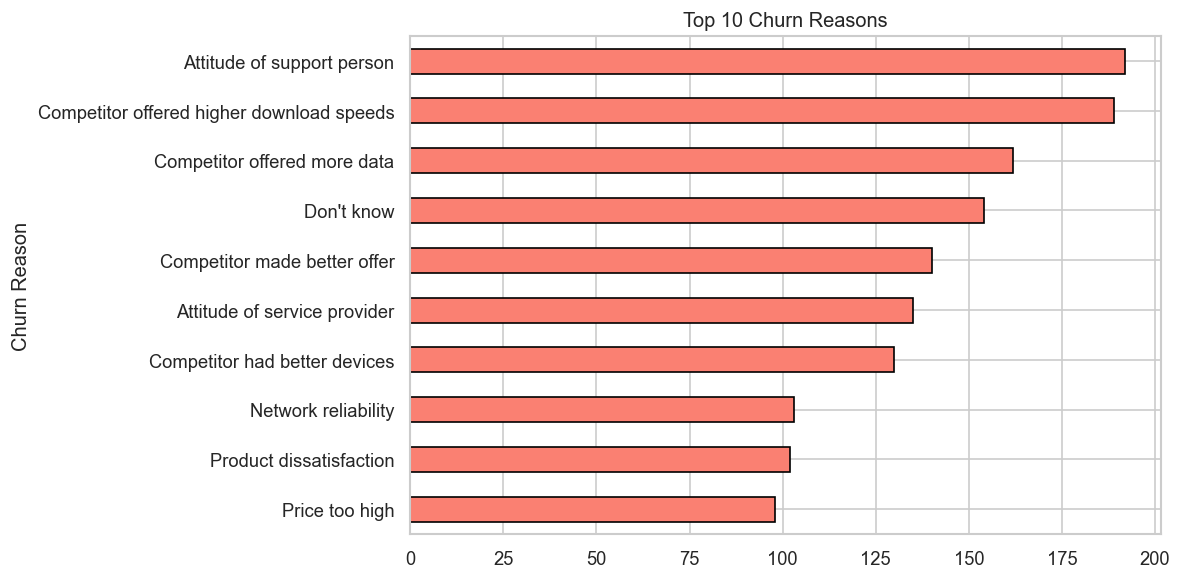

In [13]:
churn_reasons = df[df['Churn Label']=='Yes']['Churn Reason'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
churn_reasons.sort_values().plot(kind='barh', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Top 10 Churn Reasons')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'churn_reasons.png')
plt.show()

## 11. EDA Summary

In [14]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f"""
- 7,043 customers, 33 columns
- Churn rate: {df[TARGET].mean()*100:.1f}% — imbalanced
- Total Charges: object dtype → fix in cleaning
- Churn Score, CLTV: data leakage → DROP
- Country, State, Count: zero variance → DROP
- Contract month-to-month: ~43% churn
- Fiber optic internet: ~42% churn
- New customers (0-12mo): highest churn
""")

EDA SUMMARY

- 7,043 customers, 33 columns
- Churn rate: 26.5% — imbalanced
- Total Charges: object dtype → fix in cleaning
- Churn Score, CLTV: data leakage → DROP
- Country, State, Count: zero variance → DROP
- Contract month-to-month: ~43% churn
- Fiber optic internet: ~42% churn
- New customers (0-12mo): highest churn

